# MScFE 600 Financial Data - Group Work Project 1
## Executable code: Part 1 (Step 3 replication) + Part 2 (social-media sentiment EDA)

**Student Group 16339** - Sidafa Conde, Lizzie Luhanga, Saurav Pal

This notebook accompanies the PDF report. It has two sections:

* **Section A - Part 1, Step 3:** replicate a slice of Sagaceta-Mejia et al. (2024) on the
  **iShares MSCI Chile ETF (ECH)**, using **Pearson correlation** as the feature-selection
  filter and **10-fold cross-validation** with a neural-network (MLP) classifier. We reproduce
  an accuracy-vs-number-of-features **table** and the supporting **graphs**, and we run a
  **robustness check** on the choice of prediction target.
* **Section B - Part 2:** import and explore a **social-media sentiment** sample.

> **How to submit:** In Google Colab choose *Runtime -> Run all*, confirm every cell has output,
> then *File -> Print -> Save as PDF*. Zip this `.ipynb` together with that output PDF.

*Design note:* our primary target is the **next day's** Open direction, which keeps the setup
close to the paper. We show in Section A.9 why this target is optimistic and re-test the idea on
a cleaner Close-to-Close target.

### 0. Setup

In [1]:
# In Google Colab, uncomment to ensure the required packages are installed:
# !pip -q install yfinance nltk

# Standard-library and third-party imports. The aliases np, pd, plt, and sns are
# the conventional names for these libraries and are kept as-is.
import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.exceptions import ConvergenceWarning

# The MLP uses the lbfgs solver, which can emit a convergence warning on some
# folds; silence it so the notebook output stays readable.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set()

# A fixed random seed makes the cross-validation results reproducible.
RANDOM_STATE = 42

# Ticker for the fund analysed in Part 1: the iShares MSCI Chile ETF.
TICKER = "ECH"

# Directory (created if needed) where every generated figure is written.
# __file__ is available when this notebook is exported/run as a script; in a
# live notebook session, fall back to the current working directory.
try:
    NOTEBOOK_DIRECTORY = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIRECTORY = Path.cwd().resolve()
FIGURE_DIRECTORY = NOTEBOOK_DIRECTORY.parent / "figures"
os.makedirs(FIGURE_DIRECTORY, exist_ok=True)


def save_figure(filename):
    """Save the current matplotlib figure into the figures directory.

    Args:
        filename: Base file name for the image, e.g. "ech_price_history.png".

    The write is wrapped in try/except so a failure to save (for example in a
    read-only environment) never interrupts the notebook run.
    """
    try:
        plt.savefig(os.path.join(FIGURE_DIRECTORY, filename),
                    dpi=120, bbox_inches="tight")
    except Exception as error:
        print("(could not save figure:", error, ")")


print("Environment ready. Target fund:", TICKER)

Environment ready. Target fund: ECH


---
## Section A - Part 1, Step 3: Replication on ECH

### A.1 Download the data
We pull daily OHLCV for ECH from Yahoo Finance over the paper's pre-pandemic window
(2010-01-01 to 2020-01-01).

In [2]:
# Download daily OHLCV data for ECH over the paper's pre-pandemic window.
price_data = yf.download(TICKER, start="2010-01-01", end="2020-01-01",
                         auto_adjust=False, progress=False)

# Newer versions of yfinance return a column MultiIndex even for a single
# ticker; flatten it back to plain names such as "Open".
if isinstance(price_data.columns, pd.MultiIndex):
    price_data.columns = price_data.columns.get_level_values(0)
price_data = price_data.rename(columns=str)

# Cache the download next to the notebook so the analysis is reproducible.
price_data.to_csv("ECH.csv")
print("Downloaded", price_data.shape[0], "trading days;",
      "columns:", list(price_data.columns))
price_data.head()

Downloaded 2516 trading days; columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,37.070496,56.099998,56.299999,55.020000,55.570000,91800
2010-01-05,37.222473,56.330002,56.549999,56.099998,56.360001,122300
2010-01-06,37.823803,57.240002,57.330002,56.639999,56.770000,118500
2010-01-07,38.709267,58.580002,58.580002,57.150002,57.220001,653300
2010-01-08,39.237900,59.380001,59.450001,58.430000,58.700001,336000


### A.2 Price history
ECH adjusted-close price over the sample window.

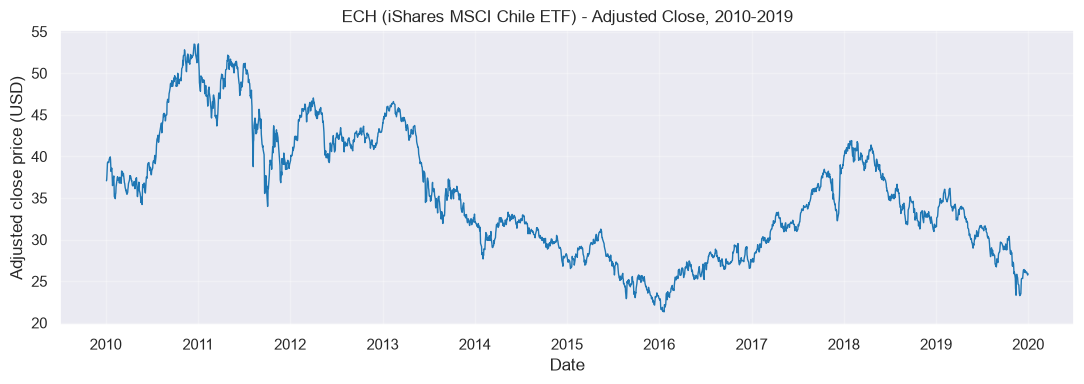

In [3]:
# Plot the adjusted-close price history so the reader can see ECH's trajectory.
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(price_data.index, price_data["Adj Close"], color="tab:blue", lw=1)
ax.set_title("ECH (iShares MSCI Chile ETF) - Adjusted Close, 2010-2019")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted close price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure("ech_price_history.png")
plt.show()

### A.3 Summary statistics
Descriptive statistics for the ECH price series, returns, and drawdown.

In [4]:
# Descriptive statistics for the price series, plus three risk/return measures.
daily_return = price_data["Adj Close"].pct_change()
summary_statistics = pd.DataFrame({
    "Open": price_data["Open"].describe(),
    "Close": price_data["Close"].describe(),
    "Adj Close": price_data["Adj Close"].describe(),
})

# Annualized volatility: daily-return standard deviation scaled by sqrt(252).
annualized_volatility = daily_return.std() * np.sqrt(252)

# Total buy-and-hold return across the whole window.
cumulative_return = price_data["Adj Close"].iloc[-1] / price_data["Adj Close"].iloc[0] - 1

# Maximum drawdown: the largest peak-to-trough decline on the adjusted-close path.
running_peak = price_data["Adj Close"].cummax()
maximum_drawdown = (price_data["Adj Close"] / running_peak - 1).min()

print("Annualized volatility: {:.1%}".format(annualized_volatility))
print("Cumulative return over window: {:.1%}".format(cumulative_return))
print("Maximum drawdown: {:.1%}".format(maximum_drawdown))
summary_statistics.round(2)

Annualized volatility: 20.8%
Cumulative return over window: -30.1%
Maximum drawdown: -60.2%


,Open,Close,Adj Close
count,2516.00,2516.00,2516.00
mean,50.07,50.06,35.30
std,12.25,12.26,7.44
min,29.30,29.62,21.32
25%,40.27,40.28,29.40
50%,46.39,46.40,33.96
75%,59.96,59.99,41.11
max,80.25,80.27,53.53


### A.4 Technical indicators (feature engineering)
The paper computes ~210 indicators with a technical-analysis library. To keep this notebook
portable (no fragile dependencies), we compute a **curated ~20-indicator** panel by hand,
spanning momentum, trend, volatility, and volume - the same families the paper's selected
features come from.

In [5]:
# Feature engineering: build a panel of ~20 technical indicators from OHLCV data.
# Each indicator summarizes a different facet of price/volume behavior (momentum,
# trend, volatility, or volume) using only information available on/before day t.
open_price = price_data["Open"]
high_price = price_data["High"]
low_price = price_data["Low"]
close_price = price_data["Close"]
volume = price_data["Volume"]

features = pd.DataFrame(index=price_data.index)

# One-day close-to-close return and price change, reused by several indicators.
close_return = close_price.pct_change()
close_change = close_price.diff()

# --- Momentum / trend / volatility indicators from the close price ---
features["ret"]   = close_return                                        # daily return
features["sma10"] = close_price.rolling(10).mean() / close_price - 1.0  # price vs 10-day SMA
features["ema10"] = close_price.ewm(span=10).mean() / close_price - 1.0 # price vs 10-day EMA
features["mom10"] = close_price / close_price.shift(10) - 1.0           # 10-day momentum
features["roc5"]  = close_price.pct_change(5)                           # 5-day rate of change
features["vol20"] = close_return.rolling(20).std()                     # 20-day volatility

# Relative Strength Index (14-day), from simple moving averages of gains/losses.
average_gain = close_change.clip(lower=0).rolling(14).mean()
average_loss = (-close_change.clip(upper=0)).rolling(14).mean()
features["rsi14"] = 100 - 100 / (1 + average_gain / average_loss.replace(0, np.nan))

# Stochastic oscillator and Williams %R use the 14-day high/low range.
highest_high = high_price.rolling(14).max()
lowest_low = low_price.rolling(14).min()
features["willr14"] = -100 * (highest_high - close_price) / (highest_high - lowest_low)  # Williams %R
features["stoch_k"] = 100 * (close_price - lowest_low) / (highest_high - lowest_low)     # Stochastic %K
features["stoch_d"] = features["stoch_k"].rolling(3).mean()                              # Stochastic %D

# Balance of Power: where the close sits within the day's open-to-range span.
features["bop"] = (close_price - open_price) / (high_price - low_price).replace(0, np.nan)

# Bollinger Band %B: the close's position inside its 20-day volatility envelope.
bollinger_mid = close_price.rolling(20).mean()
bollinger_std = close_price.rolling(20).std()
features["bbp"] = ((close_price - (bollinger_mid - 2 * bollinger_std))
                   / ((bollinger_mid + 2 * bollinger_std) - (bollinger_mid - 2 * bollinger_std)))

# 30-day z-score of the close (standard deviations from its rolling mean).
features["zscore30"] = (close_price - close_price.rolling(30).mean()) / close_price.rolling(30).std()

# On-Balance Volume, z-scored over 30 days to keep it on a comparable scale.
on_balance_volume = (np.sign(close_change).fillna(0) * volume).cumsum()
features["obv_z"] = ((on_balance_volume - on_balance_volume.rolling(30).mean())
                     / on_balance_volume.rolling(30).std())

# MACD line (fast EMA minus slow EMA) and its signal line, each scaled by price.
ema_fast = close_price.ewm(span=12).mean()
ema_slow = close_price.ewm(span=26).mean()
macd_line = ema_fast - ema_slow
features["macd"]     = macd_line / close_price
features["macd_sig"] = macd_line.ewm(span=9).mean() / close_price

# Boolean up/down flags plus simple range and volume-change features.
features["inc"]      = (close_change > 0).astype(float)                        # close rose vs prior day
features["dec"]      = (close_change < 0).astype(float)                        # close fell vs prior day
features["hl_range"] = (high_price - low_price) / close_price                  # daily high-low range
features["vchg"]     = volume.pct_change().replace([np.inf, -np.inf], np.nan)  # volume change

# Correlation Trend Indicator: correlation of price with time over a 12-day window.
features["cti12"] = close_price.rolling(12).apply(
    lambda window: np.corrcoef(window, np.arange(len(window)))[0, 1], raw=True)

print("Engineered", features.shape[1], "technical indicators")
features.tail(3).round(3)

Engineered 21 technical indicators


,ret,sma10,ema10,mom10,roc5,vol20,rsi14,willr14,stoch_k,stoch_d,...,bbp,zscore30,obv_z,macd,macd_sig,inc,dec,hl_range,vchg,cti12
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-27,-0.003,0.006,-0.001,-0.002,-0.004,0.013,65.141,-48.000,52.000,58.900,...,0.633,0.751,1.115,0.005,0.001,0.0,1.0,0.015,-0.290,-0.085
2019-12-30,-0.011,0.014,0.008,-0.025,-0.021,0.013,56.311,-68.571,31.429,47.990,...,0.538,0.420,0.856,0.004,0.002,0.0,1.0,0.015,1.662,-0.676
2019-12-31,0.007,0.005,0.001,-0.019,-0.004,0.013,60.615,-69.286,30.714,38.048,...,0.567,0.608,0.892,0.004,0.002,1.0,0.0,0.015,-0.644,-0.832


### A.5 Target label and preprocessing
The paper's class variable is the sign of the Open-price change. We predict the **next day's**
direction (`+1` up / `0` down) from today's indicators, then **min-max normalize** every
feature to [0, 1] and drop warm-up rows containing NaNs.

> **Methodological note on normalization:** the min-max scaling below uses the minimum and
> maximum of the *full* dataset, including rows that will later appear in test folds. This is a
> mild look-ahead effect. In a production pipeline you would compute the scaling parameters
> inside each fold using only training data and apply them to the held-out fold. The effect here
> is small relative to the open-gap artifact described in A.9, but it is worth stating.

In [6]:
# Prediction target: does the NEXT day's Open rise versus today's Open?
# (1 = up, 0 = down). Shifting Open by -1 aligns tomorrow's move with today's
# features, so every predictor is known before the move being classified.
next_open_direction = (open_price.shift(-1) - open_price > 0).astype(int)

# Assemble the modeling table, drop warm-up rows with NaN/inf from the rolling
# indicators, then split into the feature matrix and the target vector.
modeling_data = features.copy()
modeling_data["target"] = next_open_direction
modeling_data = modeling_data.replace([np.inf, -np.inf], np.nan).dropna()

target = modeling_data["target"]
feature_matrix = modeling_data.drop(columns="target")

# Min-max normalization scales every feature to [0, 1] so no single indicator
# dominates purely because of its units.
feature_matrix = ((feature_matrix - feature_matrix.min())
                  / (feature_matrix.max() - feature_matrix.min()))

print("Samples:", feature_matrix.shape[0], "| Features:", feature_matrix.shape[1],
      "| Share of 'up' days: {:.1%}".format(target.mean()))

Samples: 2487 | Features: 21 | Share of 'up' days: 49.1%


### A.6 Feature selection by Pearson correlation
We rank each indicator by the **absolute Pearson correlation** with the target. This is the
"easier" filter metric (the paper also uses LASSO, Chi-squared, etc.).

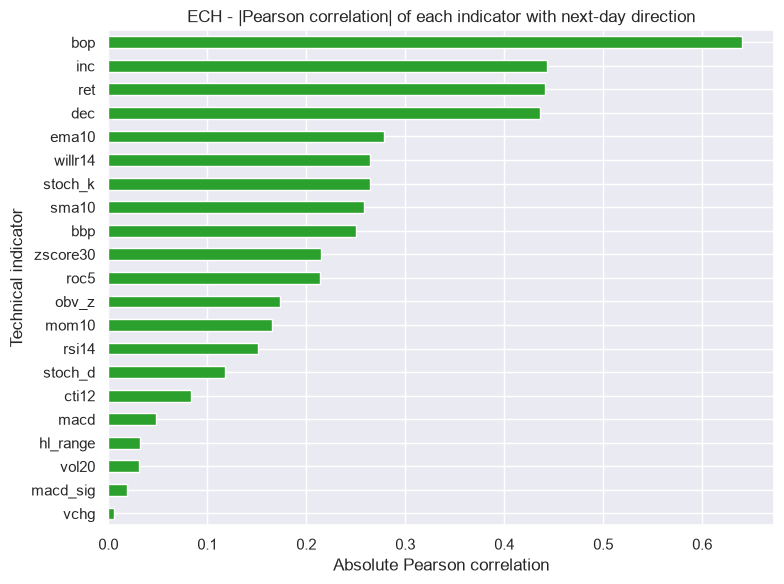

bop         0.640
inc         0.443
ret         0.441
dec         0.436
ema10       0.278
willr14     0.264
stoch_k     0.264
sma10       0.259
bbp         0.250
zscore30    0.215
roc5        0.214
obv_z       0.173
mom10       0.165
rsi14       0.151
stoch_d     0.117
cti12       0.083
macd        0.048
hl_range    0.032
vol20       0.031
macd_sig    0.018
vchg        0.005
dtype: float64

In [7]:
# Rank each indicator by the absolute Pearson correlation with the target.
# This is the "easier" filter metric used to select features.
feature_target_correlation = feature_matrix.apply(
    lambda column: np.corrcoef(column, target)[0, 1]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
feature_target_correlation.sort_values().plot.barh(ax=ax, color="tab:green")
ax.set_title("ECH - |Pearson correlation| of each indicator with next-day direction")
ax.set_xlabel("Absolute Pearson correlation")
ax.set_ylabel("Technical indicator")
plt.tight_layout()
save_figure("ech_feature_correlation.png")
plt.show()
feature_target_correlation.round(3)

### A.7 Cross-validated accuracy vs number of features
For increasing subset sizes `k` we take the top-`k` indicators by correlation, then score an
**MLP classifier** under **10-fold stratified cross-validation** (mirroring the paper's setup).
We report the **median** fold accuracy - the paper's analog of Table 4 - and compare against the
full feature set.

> **Methodological note on cross-validation:** we use `StratifiedKFold` with `shuffle=False`
> rather than a time-series-aware splitter. With this setup, fold 1 tests on the first ~248 days
> and trains on all remaining ~2,239 days, which includes observations that are *later in time*
> than the test period. Some folds therefore train on future data relative to their test window,
> which is temporal leakage. A proper time-series evaluation would use an expanding-window
> walk-forward design (`TimeSeriesSplit` or equivalent). This limitation compounds the open-gap
> artifact described in A.9: the reported accuracies are optimistic on at least two structural
> counts before the target-definition issue is even considered.

In [8]:
# Ten-fold stratified cross-validation, mirroring the paper's evaluation setup.
cross_validator = StratifiedKFold(n_splits=10, shuffle=False)


def median_cv_accuracy(feature_matrix, target, selected_features):
    """Median 10-fold accuracy of an MLP trained on a subset of features.

    Args:
        feature_matrix: DataFrame of normalized indicator values.
        target: Binary direction labels aligned with feature_matrix.
        selected_features: List of column names to train on.

    Returns:
        The median accuracy across the cross-validation folds.
    """
    # One hidden layer sized to (number of features + classes) / 2, as in the paper.
    hidden_layer_size = max(2, int((len(selected_features) + 2) / 2))
    classifier = MLPClassifier(hidden_layer_sizes=(hidden_layer_size,),
                               activation="logistic", solver="lbfgs",
                               max_iter=5000, random_state=RANDOM_STATE)
    fold_scores = cross_val_score(classifier, feature_matrix[selected_features],
                                  target, cv=cross_validator, scoring="accuracy")
    return np.median(fold_scores)


# Sweep increasing subset sizes, each time using the top-k features by correlation.
feature_subset_sizes = [2, 4, 6, 8, 10, 12, 15]
accuracy_rows = []
for subset_size in feature_subset_sizes:
    top_features = list(feature_target_correlation.head(subset_size).index)
    accuracy_rows.append({
        "n_features": subset_size,
        "median_accuracy_%": round(100 * median_cv_accuracy(feature_matrix, target, top_features), 2),
    })

# Baseline: accuracy when every engineered indicator is used.
full_set_accuracy = round(100 * median_cv_accuracy(
    feature_matrix, target, list(feature_matrix.columns)), 2)

accuracy_table = pd.DataFrame(accuracy_rows)
accuracy_table.loc[len(accuracy_table)] = {
    "n_features": feature_matrix.shape[1], "median_accuracy_%": full_set_accuracy}
accuracy_table = accuracy_table.rename(columns={
    "n_features": "Number of features", "median_accuracy_%": "Median CV accuracy (%)"})
print("Full-set ({} features) median accuracy: {:.2f}%".format(
    feature_matrix.shape[1], full_set_accuracy))
accuracy_table.reset_index(drop=True)

Full-set (21 features) median accuracy: 74.70%


,Number of features,Median CV accuracy (%)
0,2,80.12
1,4,79.72
2,6,79.68
3,8,79.72
4,10,78.92
5,12,78.51
6,15,76.71
7,21,74.70


### A.8 Accuracy-vs-features curve
Visual analog of the paper's feature-selection gain plot.

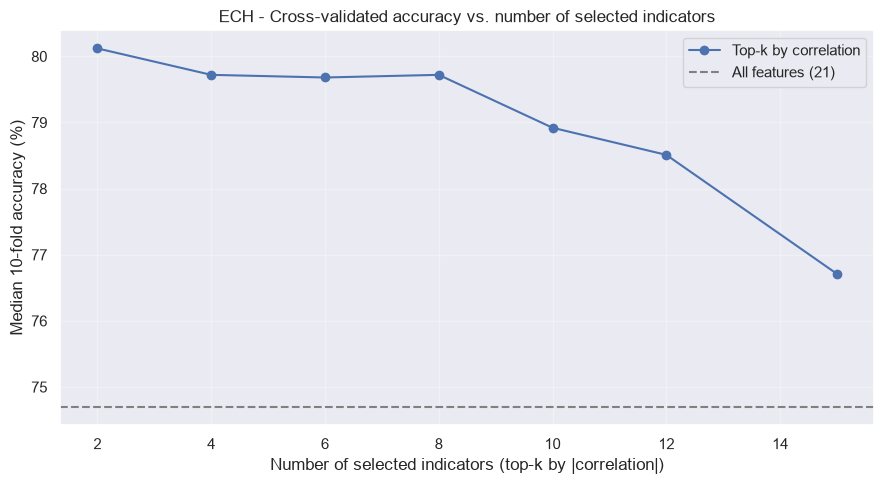

In [9]:
# Plot accuracy versus the number of selected indicators. The final row (the full
# feature set) is drawn as a horizontal reference line rather than a point.
fig, ax = plt.subplots(figsize=(9, 5))
plotted_rows = accuracy_table.iloc[:-1]
ax.plot(plotted_rows["Number of features"], plotted_rows["Median CV accuracy (%)"],
        marker="o", label="Top-k by correlation")
ax.axhline(full_set_accuracy, color="grey", ls="--",
           label="All features ({})".format(feature_matrix.shape[1]))
ax.set_title("ECH - Cross-validated accuracy vs. number of selected indicators")
ax.set_xlabel("Number of selected indicators (top-k by |correlation|)")
ax.set_ylabel("Median 10-fold accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure("ech_accuracy_vs_features.png")
plt.show()

### A.9 Robustness check - is the accuracy real, or a feature of the target?
Our next-day **Open** target has a hidden trap. The next Open is very close to today's Close, so
any indicator built from `Close - Open` (Balance of Power, the Increasing/Decreasing flags, the
daily return) nearly **encodes** the label instead of forecasting it. That mechanical link, not
genuine skill, is the likeliest reason a two-indicator model reaches ~80%.

To test this, we re-run the identical pipeline on a cleaner target: the next-day **Close-to-Close**
direction, which cannot be read off from today's close-minus-open. If the earlier accuracy was an
artifact, it should collapse toward the ~50% no-skill line here.

In [10]:
# Robustness check: repeat the analysis with a cleaner next-day Close-to-Close
# target, which cannot be recovered from today's close-minus-open gap.
close_to_close_direction = (close_price.shift(-1) - close_price > 0).astype(int)

close_to_close_data = features.copy()
close_to_close_data["target"] = close_to_close_direction
close_to_close_data = close_to_close_data.replace([np.inf, -np.inf], np.nan).dropna()
close_to_close_target = close_to_close_data["target"]
close_to_close_features = close_to_close_data.drop(columns="target")
close_to_close_features = ((close_to_close_features - close_to_close_features.min())
                           / (close_to_close_features.max() - close_to_close_features.min()))
close_to_close_correlation = close_to_close_features.apply(
    lambda column: np.corrcoef(column, close_to_close_target)[0, 1]).abs().sort_values(ascending=False)

# Compare accuracy on the two targets across the same small subset sizes.
comparison_rows = []
for subset_size in [2, 4, 6, 8, 10]:
    open_target_features = list(feature_target_correlation.head(subset_size).index)
    close_target_features = list(close_to_close_correlation.head(subset_size).index)
    comparison_rows.append({
        "Number of features": subset_size,
        "Open-to-Open acc. (%)": round(100 * median_cv_accuracy(
            feature_matrix, target, open_target_features), 2),
        "Close-to-Close acc. (%)": round(100 * median_cv_accuracy(
            close_to_close_features, close_to_close_target, close_target_features), 2),
    })
robustness_table = pd.DataFrame(comparison_rows)
print("Share of up days - Close-to-Close: {:.1%}".format(close_to_close_target.mean()))
robustness_table

Share of up days - Close-to-Close: 49.3%


,Number of features,Open-to-Open acc. (%),Close-to-Close acc. (%)
0,2,80.12,54.22
1,4,79.72,53.61
2,6,79.68,53.72
3,8,79.72,53.01
4,10,78.92,52.71


**Reading the robustness check (for the report, in your own words).** The Open-to-Open
accuracy is high, but on the cleaner Close-to-Close target the accuracy falls close to the ~50%
no-skill line. This confirms that the headline accuracy is driven mainly by the overnight-gap
link between today's close and tomorrow's open, not by real predictive power. The paper's central
*idea* - a small selected indicator set can match a larger one - still holds, but the level of
accuracy should be read with this caveat. Report the exact numbers **from your own run**.

---
## Section B - Part 2: Social-media sentiment EDA
We load a small, reproducible sample of finance social-media posts, derive sentiment with a
lexicon model (VADER), aggregate to a daily series, and explore it. *In production you would load
a full dataset (e.g. a StockTwits/Twitter research corpus) - see the Part 2 user guide.*

In [11]:
# Small illustrative sample of finance social-media posts (reproducible).
# Replace with a real research corpus for production use.
sample_posts = pd.DataFrame({
    "timestamp": pd.to_datetime([
        "2020-06-01","2020-06-01","2020-06-01","2020-06-02","2020-06-02","2020-06-03",
        "2020-06-03","2020-06-03","2020-06-04","2020-06-04","2020-06-05","2020-06-05",
        "2020-06-05","2020-06-08","2020-06-08","2020-06-09","2020-06-09","2020-06-10",
        "2020-06-10","2020-06-11","2020-06-11","2020-06-12","2020-06-12","2020-06-12"]),
    "ticker": ["SPY"]*24,
    "text": [
        "SPY looking strong, breakout incoming to the moon!",
        "Bearish on $SPY, this rally makes no sense, selling",
        "Holding my calls, bulls in control today",
        "Market crashing again, I'm scared, dumping everything",
        "Great earnings, $SPY to new highs, very bullish",
        "This dip is a gift, buying more SPY",
        "Ugh red day, bears winning, puts printing",
        "Neutral here, waiting for a clearer signal",
        "Massive rally, best day ever for my portfolio",
        "Overbought, expecting a pullback soon, cautious",
        "SPY green again, uptrend intact, loving it",
        "Fed comments spooked the market, selloff hard",
        "Buying the fear, long term bullish on stocks",
        "Choppy action, no conviction either way",
        "Breaking resistance, momentum is bullish",
        "Terrible price action, bearish reversal likely",
        "Adding to my position, confident in the trend",
        "Panic selling everywhere, ugly candles",
        "Recovery underway, dip buyers stepping in",
        "New all time highs, euphoria is real, bullish",
        "Taking profits, market feels toppy and risky",
        "Sideways grind continues, boring session",
        "Strong close, bulls defended support nicely",
        "Worried about a correction, hedging my longs"],
})
sample_posts["date"] = sample_posts["timestamp"].dt.date
print("Loaded", len(sample_posts), "sample posts")
sample_posts.head()

Loaded 24 sample posts


,timestamp,ticker,text,date
0,2020-06-01,SPY,"SPY looking strong, breakout incoming to the m...",2020-06-01
1,2020-06-01,SPY,"Bearish on $SPY, this rally makes no sense, se...",2020-06-01
2,2020-06-01,SPY,"Holding my calls, bulls in control today",2020-06-01
3,2020-06-02,SPY,"Market crashing again, I'm scared, dumping eve...",2020-06-02
4,2020-06-02,SPY,"Great earnings, $SPY to new highs, very bullish",2020-06-02


In [12]:
# Derive a sentiment score for each post with VADER, a rule-based model tuned for
# social-media text. If VADER cannot be downloaded (e.g. offline), fall back to a
# tiny keyword model so the notebook still runs end to end.
try:
    import nltk
    nltk.download("vader_lexicon", quiet=True)
    from nltk.sentiment import SentimentIntensityAnalyzer
    sentiment_analyzer = SentimentIntensityAnalyzer()
    sample_posts["compound"] = sample_posts["text"].apply(
        lambda text: sentiment_analyzer.polarity_scores(text)["compound"])
    print("Sentiment via VADER")
except Exception as error:
    print("VADER unavailable (", error, ") - using keyword fallback")
    bullish_words = ["bull","moon","strong","buy","green","rally","highs","up","confident","recovery"]
    bearish_words = ["bear","crash","sell","red","dump","puts","panic","fear","correction","toppy"]

    def keyword_sentiment(text):
        """Crude fallback sentiment in [-1, 1] from bullish/bearish word counts."""
        text = text.lower()
        return (sum(word in text for word in bullish_words)
                - sum(word in text for word in bearish_words)) / 5.0

    sample_posts["compound"] = sample_posts["text"].apply(keyword_sentiment).clip(-1, 1)

# Label each post from its compound score using a small neutral dead-band.
sample_posts["label"] = np.where(sample_posts["compound"] > 0.05, "Bullish",
                          np.where(sample_posts["compound"] < -0.05, "Bearish", "Neutral"))
sample_posts[["date","text","compound","label"]].head()

Sentiment via VADER


,date,text,compound,label
0,2020-06-01,"SPY looking strong, breakout incoming to the m...",0.5562,Bullish
1,2020-06-01,"Bearish on $SPY, this rally makes no sense, se...",-0.2960,Bearish
2,2020-06-01,"Holding my calls, bulls in control today",0.0000,Neutral
3,2020-06-02,"Market crashing again, I'm scared, dumping eve...",-0.6369,Bearish
4,2020-06-02,"Great earnings, $SPY to new highs, very bullish",0.6249,Bullish


In [13]:
# Aggregate the posts into a daily panel: message volume and mean sentiment.
daily_sentiment = (sample_posts.groupby("date")
                   .agg(msg_volume=("text", "size"),
                        mean_sentiment=("compound", "mean"))
                   .reset_index())
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
daily_sentiment

,date,msg_volume,mean_sentiment
0,2020-06-01,3,0.086733
1,2020-06-02,2,-0.006000
2,2020-06-03,3,0.197833
3,2020-06-04,2,0.267100
4,2020-06-05,3,0.031400
5,2020-06-08,2,-0.148000
6,2020-06-09,2,0.008600
7,2020-06-10,2,-0.382500
8,2020-06-11,2,0.460900
9,2020-06-12,3,0.073933


### B.1 EDA plots

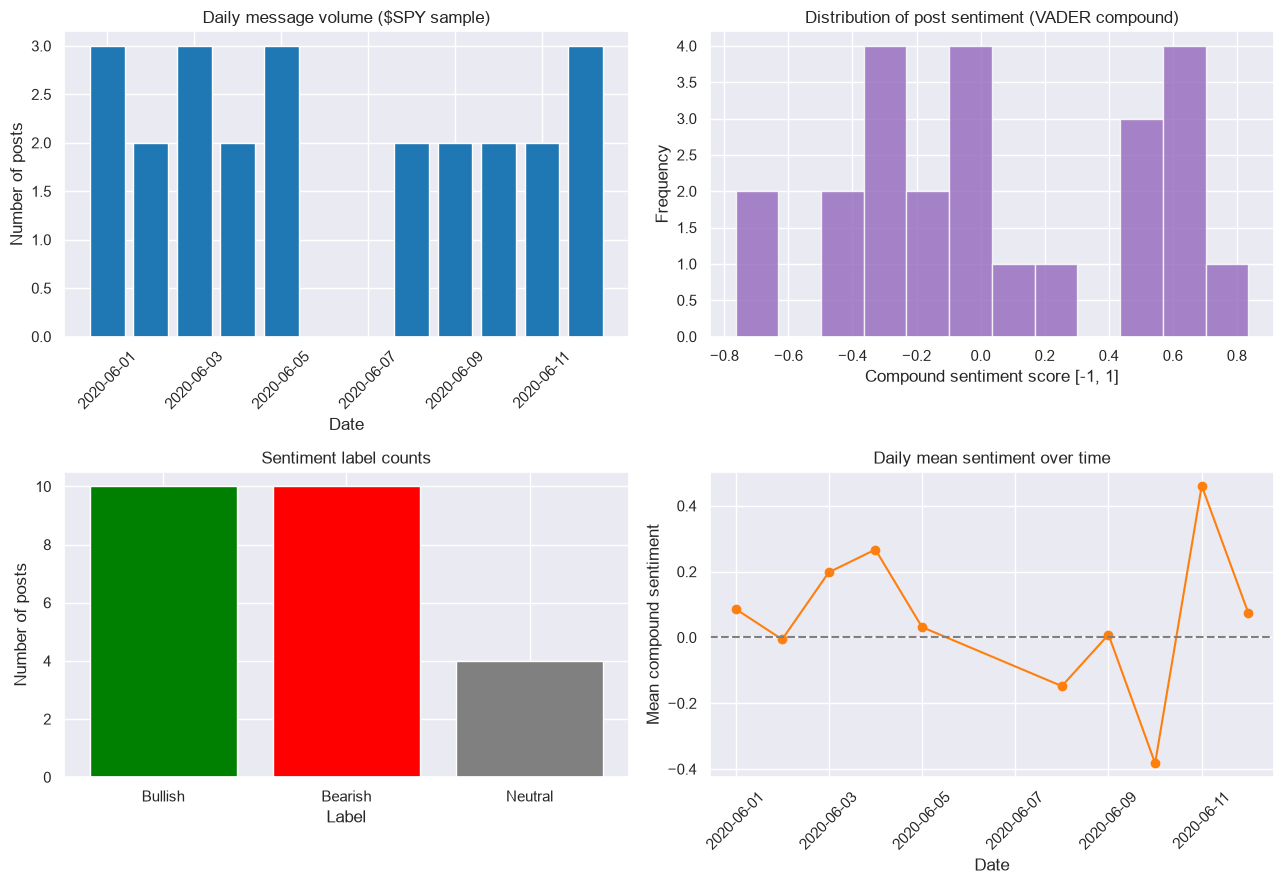

In [14]:
# Four exploratory views of the sample: message volume, sentiment distribution,
# label balance, and daily mean sentiment over time.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) message volume over time
axes[0,0].bar(daily_sentiment["date"], daily_sentiment["msg_volume"], color="tab:blue")
axes[0,0].set_title("Daily message volume ($SPY sample)")
axes[0,0].set_xlabel("Date"); axes[0,0].set_ylabel("Number of posts")
axes[0,0].tick_params(axis="x", rotation=45)

# (2) sentiment distribution
axes[0,1].hist(sample_posts["compound"], bins=12, color="tab:purple", alpha=0.8)
axes[0,1].set_title("Distribution of post sentiment (VADER compound)")
axes[0,1].set_xlabel("Compound sentiment score [-1, 1]"); axes[0,1].set_ylabel("Frequency")

# (3) bull/bear/neutral balance
label_counts = sample_posts["label"].value_counts()
axes[1,0].bar(label_counts.index, label_counts.values, color=["green","red","grey"])
axes[1,0].set_title("Sentiment label counts")
axes[1,0].set_xlabel("Label"); axes[1,0].set_ylabel("Number of posts")

# (4) daily mean sentiment over time
axes[1,1].plot(daily_sentiment["date"], daily_sentiment["mean_sentiment"], marker="o", color="tab:orange")
axes[1,1].axhline(0, color="grey", ls="--")
axes[1,1].set_title("Daily mean sentiment over time")
axes[1,1].set_xlabel("Date"); axes[1,1].set_ylabel("Mean compound sentiment")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_figure("sentiment_eda.png")
plt.show()

**Reading the results (for the report, in your own words).** Describe the sentiment
distribution (balance of bullish vs bearish), how message volume moves day to day, and - with a
*real* dataset - whether daily sentiment shows any lead/lag relationship with returns. Emphasize
that social sentiment is a **weak, noisy** signal, most useful as an attention/volume proxy.

---
### References
* Sagaceta-Mejia, A. R., Sanchez-Gutierrez, M. E., & Fresan-Figueroa, J. A. (2024).
  *An Intelligent Approach for Predicting Stock Market Movements in Emerging Markets Using
  Optimized Technical Indicators and Neural Networks.* Economics, 18(1).
* Sun, Y., et al. (2024). *Alternative Data in Finance and Business: Emerging Applications and
  Theory Analysis (Review).* Financial Innovation, 10.

*See `report/references.md` for the full MLA bibliography.*